# Projected Bures--Wasserstein Gradient Descent

Companion notebook for the article *Projected Riemannian Gradient Descent for the Bures--Wasserstein barycenter: Dimension-Independent Linear Convergence at Unit Step Size*.

The algorithm is unit-step Riemannian gradient descent on the Bures--Wasserstein manifold, composed at every iteration with eigenvalue clipping onto the well-conditioned set $\{S : \alpha I \preceq S \preceq \beta I\}$:

$$S_{t+1} = \mathrm{clip}_{[\alpha,\beta]}\big[\mathrm{K}(S_t)\big], \qquad \mathrm{K}(S) = S^{-1/2}\Big[\sum_i w_i (S^{1/2} R_i S^{1/2})^{1/2}\Big]^2 S^{-1/2}.$$

Clipping is not a heuristic safeguard: it is the exact, non-expansive projection in the Bures metric, which is what makes the dimension-free rate at unit step size possible.

# Installations and Definitions

In [1]:
# Picks up edits to prgd.py and prgdplots.py without restarting the kernel
%load_ext autoreload
%autoreload 2

# On Colab, uncomment the next line to fetch prgd.py and prgdplots.py
# !git clone -q https://github.com/afhamash/projected-rgd.git && cd projected-rgd

import numpy as np
from matplotlib import pyplot as plt

import prgd
from prgd import *  # noqa: F403
from prgdplots import fig_headline, fig_unit_vs_small, fig_exit_trajectory

use_style()
np.set_printoptions(precision=4)

### Notation

`ensemble` : the ensemble $(R_1, \ldots, R_n)$, an `(n,d,d)` array \\
`w` : the weight vector over the ensemble \\
`S` : the current iterate \\
`alpha, beta` : the spectral bounds $\min_i \lambda_{\min}(R_i)$ and $\max_i \lambda_{\max}(R_i)$ \\
`alpha_ref, beta_ref` : the refined bounds $\alpha' = [\sum_i w_i \sqrt{\lambda_{\min}(R_i)}]^2$ and $\beta' = \lambda_{\max}(\sum_i w_i R_i)$

# Numerics

## Minimal working example

In [2]:
# A random ensemble with every matrix of condition number exactly kappa
n, d, kappa = 5, 6, 100.0

ensemble = pinned_ensemble(n, d, kappa, make_rng("demo", d, n, kappa, 0))
w = np.full(n, 1 / n)

alpha, beta = interval_bounds(ensemble)
alpha_ref, beta_ref = refined_bounds(ensemble, w)

print(f"alpha = {alpha:.4f}, beta = {beta:.1f}, kappa = {beta / alpha:.1f}")
print(f"alpha' = {alpha_ref:.4f}, beta' = {beta_ref:.2f}, kappa' = {beta_ref / alpha_ref:.1f}")

alpha = 1.0000, beta = 100.0, kappa = 100.0
alpha' = 1.0000, beta' = 53.13, kappa' = 53.1


In [3]:
# Projected BW-GD from the midpoint of the interval
path, n_clipped = projected_bw_gd(ensemble, w, alpha, beta, n_iters=20)

S_star = barycenter(ensemble, w)
f_star = barycenter_functional(S_star, ensemble, w)
gaps = [barycenter_functional(S, ensemble, w) - f_star for S in path]

print(f"projection was active on {n_clipped} of 20 steps")
for t in [1, 2, 5, 10, 20]:
    print(f"  t = {t:2d}:  f(S_t) - f(S*) = {gaps[t]:.3e}")

projection was active on 0 of 20 steps
  t =  1:  f(S_t) - f(S*) = 1.344e-01
  t =  2:  f(S_t) - f(S*) = 8.972e-03
  t =  5:  f(S_t) - f(S*) = 1.088e-05
  t = 10:  f(S_t) - f(S*) = 3.267e-10
  t = 20:  f(S_t) - f(S*) = -2.487e-14


In [4]:
# The unit step against the small step of Altschuler et al.
eta_small = small_step_size(ensemble, w)
path_small, _ = projected_bw_gd(ensemble, w, alpha, beta, eta=eta_small, n_iters=4000, project=False)
gaps_small = [barycenter_functional(S, ensemble, w) - f_star for S in path_small]

tolerance = 1e-10 * gaps[0]
t_unit = next(t for t, g in enumerate(gaps) if g <= tolerance)
t_small = next(t for t, g in enumerate(gaps_small) if g <= tolerance)

assert t_small > 100 * t_unit, (t_unit, t_small)
print(f"small step size eta = {eta_small:.3e}")
print(f"iterations to a relative gap of 1e-10:  unit {t_unit},  small {t_small}  ({t_small / t_unit:.0f}x)")

small step size eta = 9.410e-03
iterations to a relative gap of 1e-10:  unit 10,  small 1584  (158x)


# Figures

## Figure 1 — the headline figure

Panel (a): the optimality gap of unit-step against small-step RGD ($\eta = \alpha'/(2\beta')$) on thirty instances of the pinned $d = 2$ family ($n = 5$, $\kappa = 100$; every member with spectrum $\{\alpha, \beta\}$ in a Haar-random eigenbasis), translucent per instance with the medians opaque. At the median the unit step reaches the double-precision floor in about 16 iterations, the small step in about 3300; both converge linearly, so the per-instance factor (median 202) is the ratio of their rates.

Panel (b): the certified exit instance ($\kappa = 300$), drawn as the signed deviation $\lambda_{\min}(S_t) - \alpha$. The unprojected unit-step iterates fall below $\alpha$ at $t = 1, 2$, re-enter at $t = 3$, and converge to a strictly interior limit; the inset shows the full two-eigenvalue picture against the band $[\alpha, \beta]$.

The thirty runs take a few minutes.

'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


(a) medians over 30 instances: unit reaches the floor at t = 16, small at t = 3330 (208x)
    per-instance iteration ratio at the floor: median 202, range 141 to 399
(b) lambda_min - alpha at t = 1, 2, 3: -2.984e-01, -4.434e-03, 2.117e-03; limit 2.524e-03
wrote figures/fig_headline.pdf and .png


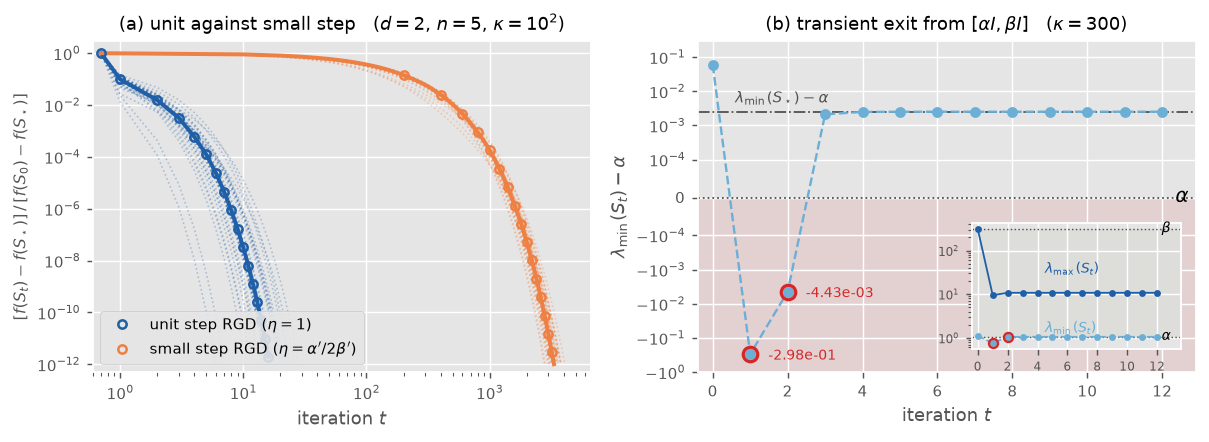

In [5]:
fig_headline()

## Figure 2 — unit against small step, across $\kappa$ and $d$

Graded by conditioning in panel (a) and by dimension in panel (b), on pinned ensembles so the refined constants stay comparable. The unit-step counts are flat in the dimension, as the theorem asserts.

This reads the cached sweeps in `data/`; recomputing them takes about six minutes for (a) and over an hour for (b).

'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


wrote figures/fig_unit_vs_small.pdf and .png


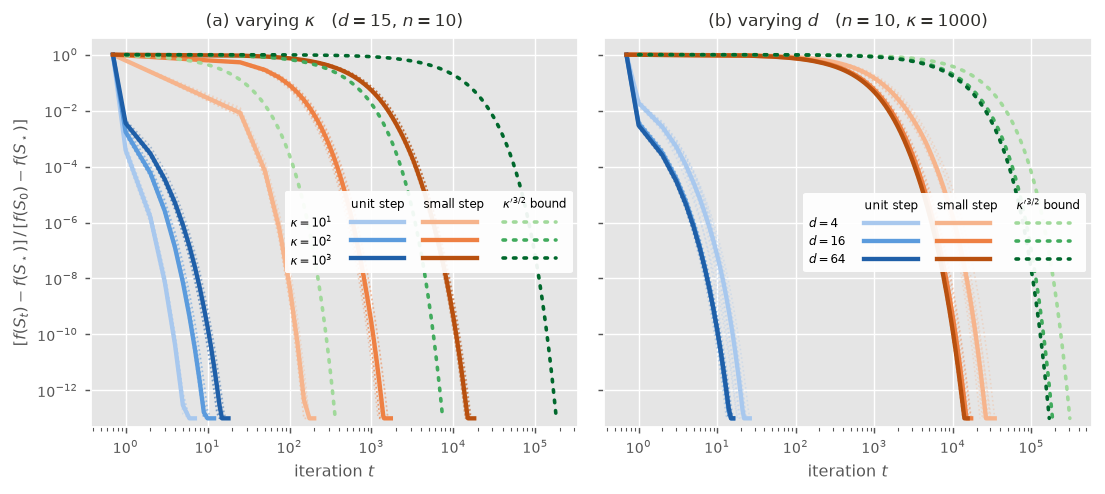

In [6]:
fig_unit_vs_small()

## Figure 3 — the exit trajectory

Both eigenvalues along the unprojected trajectory, with the feasible band shaded. The inset resolves the two undershoots against the certified interior floor of the optimum. This is the same instance as panel (b) of the headline figure, in its raw two-eigenvalue view.

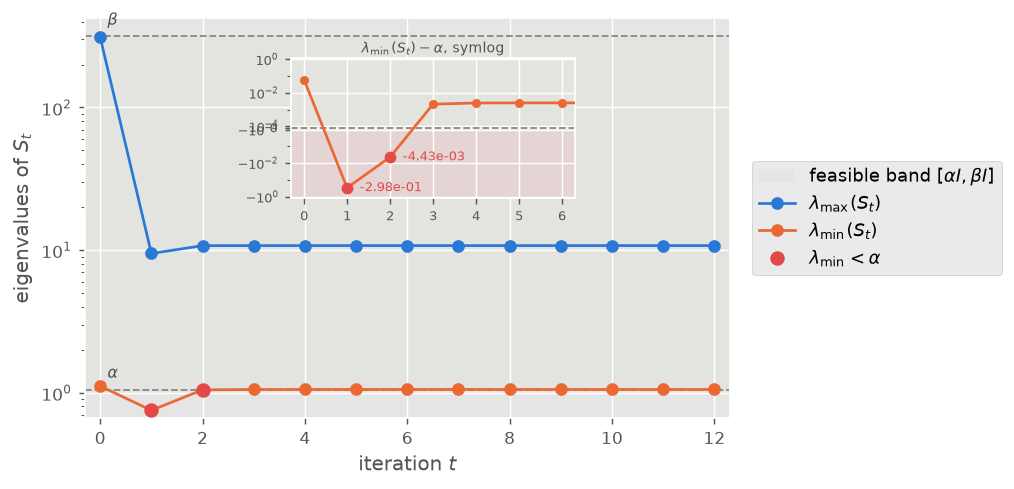

iterates with lambda_min < alpha: t = [1, 2]
wrote figures/fig_exit_trajectory.pdf and .png


In [7]:
fig_exit_trajectory()

## Verifying Example 13

A from-scratch check of the exit instance: the ensemble, weights, and start are typed in below — nothing is taken from `prgdplots` — and only the unprojected map `bw_map` is imported. Both certificates locating the barycenter strictly inside $[\alpha I, \beta I]$ — the floor $\alpha' = [\sum_i w_i \sqrt{\lambda_{\min}(R_i)}]^2$ (also the refined floor) and the ceiling $[\sum_i w_i \sqrt{\lambda_{\max}(R_i)}]^2$ — are computed inline, and $\lambda_{\min}$ is recorded for every iterate. The assertions fail loudly if any claim of the example is off.

In [8]:
# Example 13, verified from scratch: the instance is typed in below, only the
# unprojected unit-step map is imported, and every certificate is computed inline.
from prgd import bw_map

def Q(theta):
    """The rotation matrix of the example, in the paper's convention."""
    return np.array([[np.cos(theta), np.sin(theta)],
                     [-np.sin(theta), np.cos(theta)]])

def conjugate(theta, eigenvalues):
    return (Q(theta) @ np.diag(eigenvalues) @ Q(theta).T).astype(complex)

ensemble = np.array([conjugate(0.246, [1.05, 315.0]),
                     conjugate(0.338, [1.0501, 1.575]),
                     conjugate(0.253, [1.0502, 4.41])])
w = np.array([0.12, 0.827, 0.053])
S = conjugate(1.473, [1.11, 310.0])
alpha, beta = 1.05, 315.0
print(f"alpha = {alpha}, beta = {beta}, kappa = {beta / alpha:.0f}")

# the certificates locating the optimum strictly inside [alpha I, beta I]:
# floor   alpha' = [sum_i w_i sqrt(lambda_min(R_i))]^2   (also the refined floor)
# ceiling          [sum_i w_i sqrt(lambda_max(R_i))]^2   (Altschuler et al., Thm. 6)
spectra = [np.linalg.eigvalsh(R) for R in ensemble]
alpha_ref = float(sum(wi * np.sqrt(lam.min()) for wi, lam in zip(w, spectra)) ** 2)
ceiling = float(sum(wi * np.sqrt(lam.max()) for wi, lam in zip(w, spectra)) ** 2)
print(f"floor certificate:   alpha' - alpha = {alpha_ref - alpha:.3e}   (paper: 9.33e-05)")
print(f"ceiling certificate: {ceiling:.2f}   (paper: 10.75)")

# minimal eigenvalue of every unprojected iterate (index = iteration)
lam_min = [float(np.linalg.eigvalsh(S).min())]
for _ in range(3000):
    S = bw_map(S, ensemble, w)
    lam_min.append(float(np.linalg.eigvalsh(S).min()))

print("lambda_min(S_t) - alpha at t = 1, 2, 3:",
      ", ".join(f"{lam_min[t] - alpha:+.3e}" for t in (1, 2, 3)),
      "  (paper: -2.984e-01, -4.434e-03, +2.117e-03)")
print("iterates below alpha:", [t for t, l in enumerate(lam_min) if l < alpha],
      "  (paper: t = 1, 2)")
print(f"limit: lambda_min - alpha = {lam_min[-1] - alpha:+.3e}   (paper: +2.52e-03)")

# the exit lasts exactly two steps, both undershoots lie below even the
# certified floor alpha', and the limit respects both certificates
assert [t for t, l in enumerate(lam_min) if l < alpha] == [1, 2]
assert lam_min[1] < alpha_ref and lam_min[2] < alpha_ref
assert alpha_ref <= lam_min[-1] and np.linalg.eigvalsh(S).max() <= ceiling
print("all assertions passed")

alpha = 1.05, beta = 315.0, kappa = 300
floor certificate:   alpha' - alpha = 9.330e-05   (paper: 9.33e-05)
ceiling certificate: 10.75   (paper: 10.75)
lambda_min(S_t) - alpha at t = 1, 2, 3: -2.984e-01, -4.434e-03, +2.117e-03   (paper: -2.984e-01, -4.434e-03, +2.117e-03)
iterates below alpha: [1, 2]   (paper: t = 1, 2)
limit: lambda_min - alpha = +2.524e-03   (paper: +2.52e-03)
all assertions passed
